# Train, predict, score, and evaluate a Transformer on PLAsTiCC

This notebook uses the `dlip_plasticc` package on top of `avocado`.

In [16]:
# Notebook parameters

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# Training
TRAIN_DATASET_NAME = 'plasticc_augment'
CLASSIFIER_NAME = 'my_transformer_seq'
SEQ_LEN = 350
NUM_EPOCHS = 100
BATCH_SIZE = 64
LR = 1e-4
NUM_FOLDS = 5
RANDOM_STATE = 42
VAL_FOLD = 0
WEIGHT_DECAY = 1e-2
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
MIN_LR = 1e-6
EARLY_STOPPING_PATIENCE = 20

# Transformer architecture
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 4
DIM_FEEDFORWARD = 256
DROPOUT = 0.2

# Prediction
TEST_DATASET_NAME = 'plasticc_test'
TOTAL_CHUNKS = 500

# Change this list to the chunks you actually want to run.
# For a quick smoke test, use something like [0, 1, 2].
CHUNKS = range(21)

# Output location for per-chunk and combined predictions.
OUT_DIR = 'notebook_outputs/transformer_predictions'

# Confusion matrix display options
CONFUSION_NORMALIZE = 'true'  # one of: None, 'true', 'pred', 'all'
FIGSIZE_HISTORY = (8, 5)
FIGSIZE_CONFUSION = (10, 8)


In [5]:
!pip install tomli

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.features import PlasticcSequenceFeaturizer
from dlip_plasticc.models import TransformerClassifier
from dlip_plasticc.pipelines.predict import predict_partial_from_dataset
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [9]:
# Load config and push paths into avocado
cfg = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(cfg)

print('Using avocado paths:')
print('  data_directory       =', avocado.settings['data_directory'])
print('  features_directory   =', avocado.settings['features_directory'])
print('  predictions_directory=', avocado.settings['predictions_directory'])
print('  classifier_directory =', avocado.settings['classifier_directory'])


Using avocado paths:
  data_directory       = /scratch/s4339150/plasticc/data
  features_directory   = /scratch/s4339150/plasticc/features
  predictions_directory= /scratch/s4339150/plasticc/predictions
  classifier_directory = /scratch/s4339150/plasticc/classifiers


## 1. Train the Transformer

This uses online sequence featurization from raw observations in the training dataset.

In [10]:
featurizer = PlasticcSequenceFeaturizer(seq_len=SEQ_LEN)

classifier = TransformerClassifier(
    name=CLASSIFIER_NAME,
    featurizer=featurizer,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
)

print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
train_dataset = avocado.load(TRAIN_DATASET_NAME)

print('Extracting sequence raw features...')
train_dataset.extract_raw_features(featurizer)

print(f"Training classifier '{CLASSIFIER_NAME}'...")
classifier.train(
    train_dataset,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

print(f"Best validation loss: {classifier.best_val_loss:.5f}")


Loading training dataset 'plasticc_augment'...
Extracting sequence raw features...


Object: 100%|██████████| 66532/66532 [00:49<00:00, 1351.03it/s]


Training classifier 'my_transformer_seq'...


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home6/s4339150/miniconda/envs/project/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
Epochs:   1%|          | 1/100 [00:13<21:36, 13.10s/it]

Epoch 1 train_loss: 1.58814 val_loss: 1.35863 val_acc: 0.53527 lr: 1.000000e-04


...

Epoch 61 train_loss: 0.65861 val_loss: 0.80066 val_acc: 0.73513 lr: 1.000000e-06


Epochs:  62%|██████▏   | 62/100 [28:36<19:23, 30.63s/it]

Epoch 62 train_loss: 0.65958 val_loss: 0.80302 val_acc: 0.73386 lr: 1.000000e-06


Epochs:  62%|██████▏   | 62/100 [29:07<17:50, 28.18s/it]

Epoch 63 train_loss: 0.66061 val_loss: 0.80045 val_acc: 0.73483 lr: 1.000000e-06
Early stopping at epoch 63. Best val_loss: 0.79686
Best validation loss: 0.79686
Best validation loss: 0.79686


In [11]:
# Save the trained classifier
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)


Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_transformer_seq.pkl


## 2. Plot training history

In [17]:
history = classifier.history.copy()
history.tail()

,epoch,train_loss,val_loss,val_acc,lr
58,59,0.660250,0.800111,0.736555,0.000001
59,60,0.660815,0.801342,0.736330,0.000001
60,61,0.658612,0.800660,0.735134,0.000001
61,62,0.659583,0.803023,0.733862,0.000001
62,63,0.660612,0.800454,0.734834,0.000001


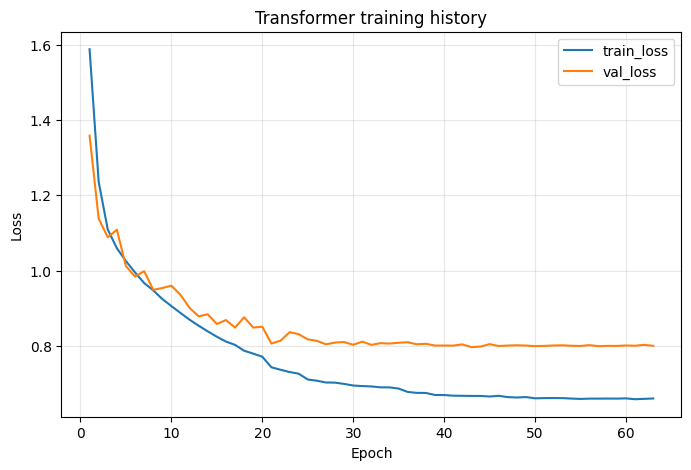

In [18]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['train_loss'], label='train_loss')
ax.plot(history['epoch'], history['val_loss'], label='val_loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Transformer training history')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


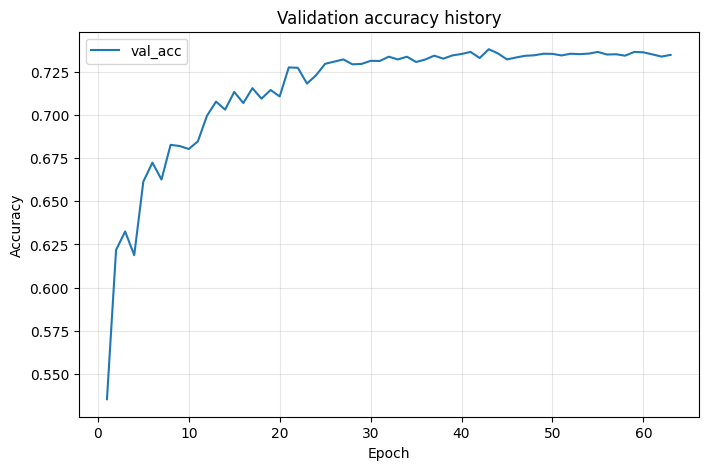

In [19]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['val_acc'], label='val_acc')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Validation accuracy history')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 3. Predict on test chunks

In [20]:
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

combined_predictions, processed_chunks = predict_partial_from_dataset(
    classifier=classifier,
    featurizer=featurizer,
    dataset_name=TEST_DATASET_NAME,
    total_chunks=TOTAL_CHUNKS,
    chunks=CHUNKS,
    out_dir=OUT_DIR,
    metadata_only=False,
    show_progress=True,
)

print('Processed chunks:', processed_chunks)
print('Combined prediction shape:', combined_predictions.shape)
combined_predictions.head()


Chunks: 100%|██████████| 21/21 [02:35<00:00,  7.40s/it]

Processed chunks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Combined prediction shape: (146701, 14)


,6,15,16,42,52,53,62,64,65,67,88,90,92,95
object_id,,,,,,,,,,,,,,
plasticc_000000013,0.000005,0.000015,1.529821e-07,0.839394,0.084369,1.391575e-10,0.014741,1.388448e-08,0.000007,0.000046,0.000029,0.048986,1.278870e-09,0.012409
plasticc_000000014,0.000151,0.003826,6.776928e-06,0.567829,0.081164,2.216366e-08,0.049495,1.779709e-04,0.003879,0.003554,0.000249,0.287971,1.564283e-07,0.001698
plasticc_000000017,0.000047,0.001776,4.112706e-06,0.184338,0.078765,4.690680e-10,0.019170,3.447631e-05,0.001112,0.004648,0.000314,0.709277,7.838297e-08,0.000513
plasticc_000000023,0.000303,0.001272,1.677074e-06,0.105529,0.023451,4.700099e-09,0.098018,4.717181e-05,0.000077,0.099074,0.000025,0.643432,3.504704e-08,0.028772
plasticc_000000034,0.000004,0.000042,1.878389e-08,0.020756,0.027566,6.907202e-13,0.001114,2.820125e-07,0.000020,0.000423,0.000002,0.950024,1.258399e-09,0.000048


## 4. Score predictions with avocado flat-weighted logloss

This scores only on the overlapping labeled objects available in the metadata.

In [21]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, combined_predictions)
print(f'Flat-weighted logloss: {flat_score:.5f}')
print(f'Objects scored:        {n_scored:,}')


Flat-weighted logloss: 1.23067
Objects scored:        146,085


## 5. Confusion matrix

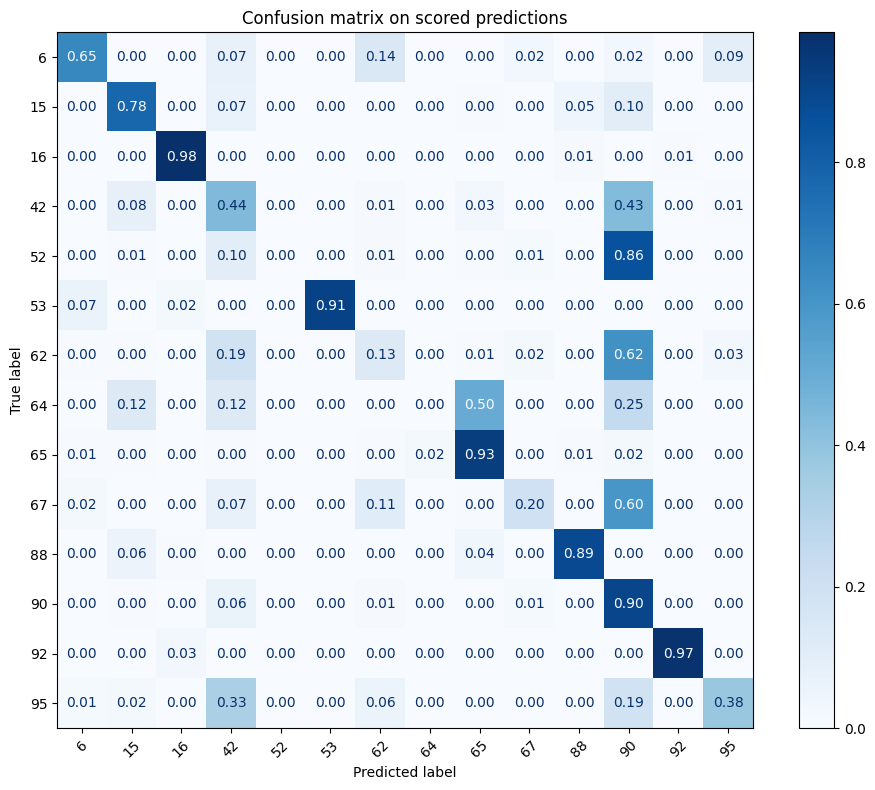

In [23]:
y_true, pred_aligned = align_truth_and_predictions(
    TEST_DATASET_NAME,
    combined_predictions,
    known_classes_only=True,
    normalize=True,
)

y_pred = pred_aligned.idxmax(axis=1)
labels = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=True,
    cmap=plt.cm.Blues,
    values_format=".2f",
)

ax.set_title("Confusion matrix on scored predictions")
plt.tight_layout()
plt.show()

In [24]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           6     0.0683    0.6512    0.1236        43
          15     0.0780    0.7766    0.1418       479
          16     0.9403    0.9839    0.9616      3233
          42     0.7661    0.4403    0.5592     48142
          52     0.0000    0.0000    0.0000      2864
          53     0.9767    0.9130    0.9438        46
          62     0.4128    0.1302    0.1979      7859
          64     0.0000    0.0000    0.0000         8
          65     0.6243    0.9325    0.7479      3095
          67     0.2243    0.1973    0.2099      1673
          88     0.9651    0.8878    0.9249      3743
          90     0.6712    0.9027    0.7699     66848
          92     0.9955    0.9707    0.9829      6781
          95     0.4385    0.3784    0.4062      1271

    accuracy                         0.6831    146085
   macro avg     0.5115    0.5832    0.4978    146085
weighted avg     0.6937    0.6831    0.6604    146085



## 6. Optional: Save combined predictions to a separate CSV

Useful if you want a quick export without opening the HDF file.

In [ ]:
csv_path = Path(OUT_DIR) / 'predictions_combined.csv'
combined_predictions.to_csv(csv_path)
print('Wrote:', csv_path)